In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('placement.csv')
df.head()

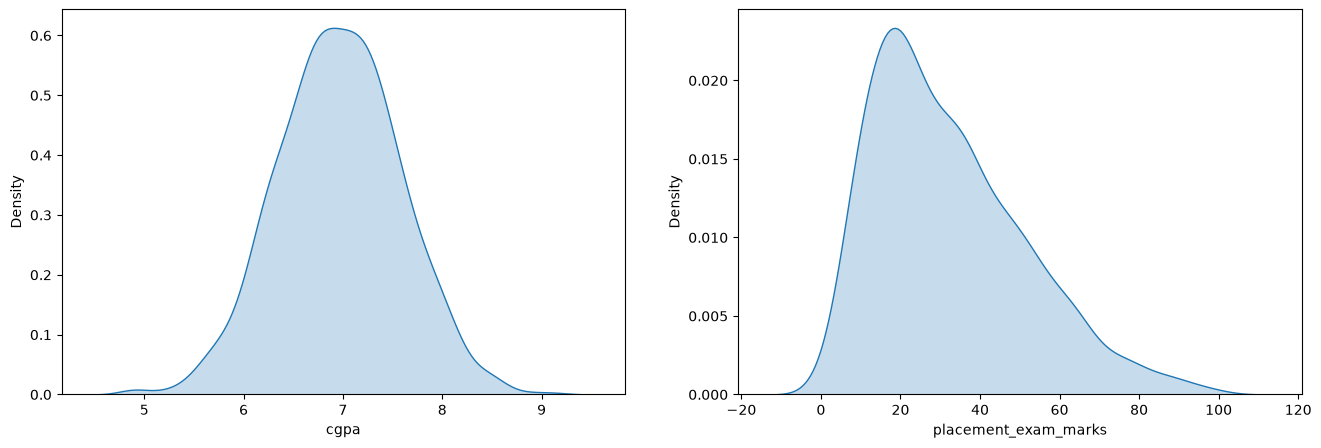

In [ ]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'],fill=True)

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'],fill=True)

plt.show()

In [ ]:
# Check the skewness of the feature to understand its distribution
# Skewness Interpretation:
# ≈ 0      -> Symmetric (Normally Distributed)
# -0.5 to 0.5  -> Approximately Symmetric
# -1 to -0.5   -> Moderately Left-Skewed (Negative Skew)
# 0.5 to 1     -> Moderately Right-Skewed (Positive Skew)
# < -1         -> Highly Left-Skewed
# > 1          -> Highly Right-Skewed

df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [ ]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

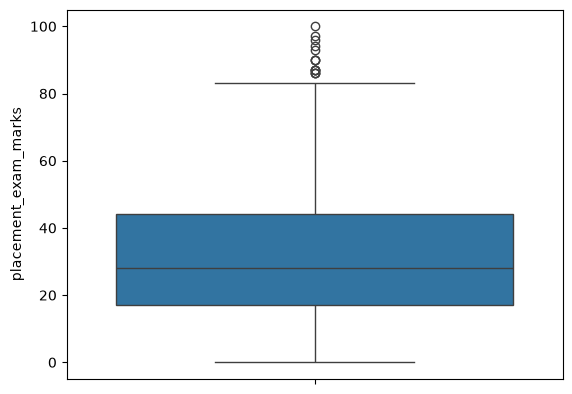

In [ ]:
sns.boxplot(df['placement_exam_marks'])

In [ ]:
# Finding 25th and 75th Percentile Value
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [ ]:
percentile75

np.float64(44.0)

In [ ]:
# Finding the IQR
iqr = percentile75 - percentile25

In [ ]:
iqr

np.float64(27.0)

In [ ]:
# Calculating Maximum and Minimum
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [ ]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


## Finding Outliers

In [ ]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [ ]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


## Trimming

In [ ]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [ ]:
new_df.shape

(985, 3)

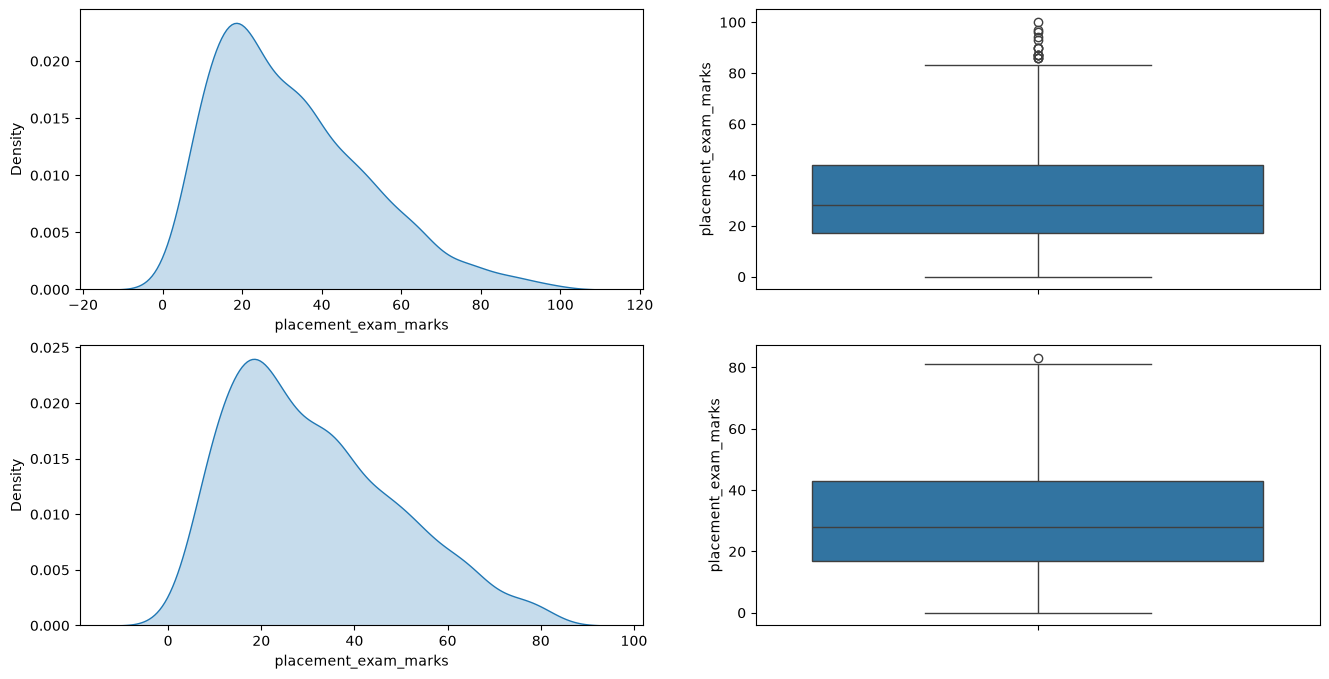

In [ ]:
# Comparing Visually
plt.figure(figsize=(16,8))
#         Column 1             Column 2
#      +----------------+----------------+
# Row1 |       1        |       2        |
#      |  (Top Left)    | (Top Right)    |
#      +----------------+----------------+
# Row2 |       3        |       4        |
#      | (Bottom Left)  |(Bottom Right)  |
#      +----------------+----------------+
plt.subplot(2,2,1)
sns.kdeplot(df['placement_exam_marks'],fill=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.kdeplot(new_df['placement_exam_marks'],fill=True)

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

## Capping

In [ ]:
new_df_cap = df.copy()
# np.where(condition, value_if_true, value_if_false)
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [ ]:
new_df_cap.shape

(1000, 3)

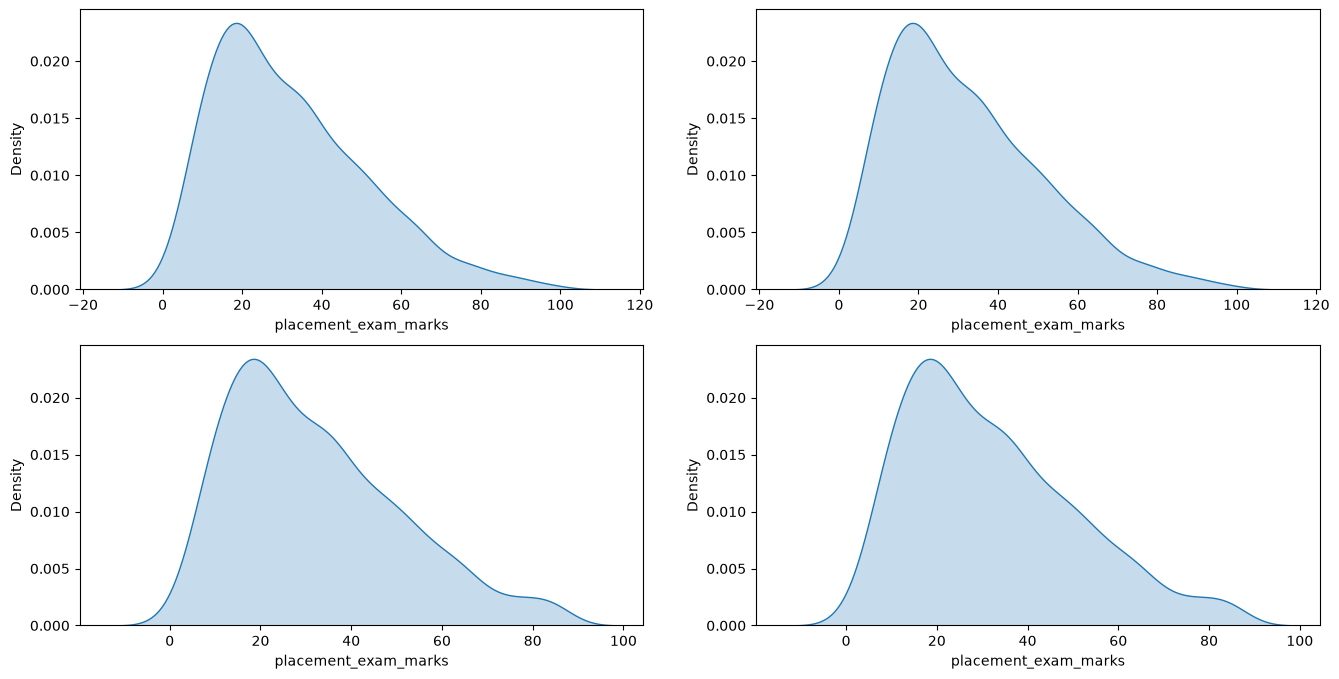

In [ ]:
# Comparing Visually

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.kdeplot(df['placement_exam_marks'],fill=True)

plt.subplot(2,2,2)
sns.kdeplot(df['placement_exam_marks'],fill=True)

plt.subplot(2,2,3)
sns.kdeplot(new_df_cap['placement_exam_marks'],fill=True)

plt.subplot(2,2,4)
sns.kdeplot(new_df_cap['placement_exam_marks'],fill=True)

plt.show()